#Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.
• Select one image randomly from each class.
• Display the images in a grid format with two rows using matplotlib.

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.metrics import classification_report

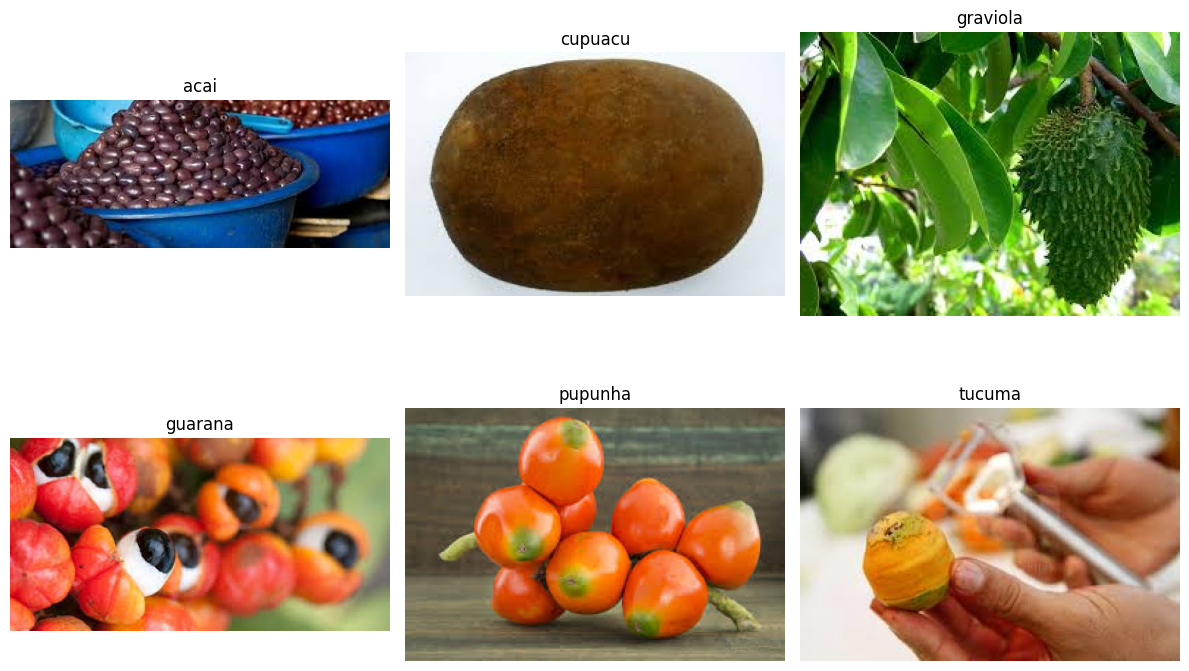

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Observation: Images vary in size, background, and lighting across classes.


In [5]:
train_path = '/content/drive/MyDrive/AI and Machine Learning/Workshop_5/FruitinAmazon/train'
test_path  = '/content/drive/MyDrive/AI and Machine Learning/Workshop_5/FruitinAmazon/test'

category_list = sorted(os.listdir(train_path))
total_categories = len(category_list)

num_cols = (total_categories + 1) // 2
figure, ax_array = plt.subplots(2, num_cols, figsize=(num_cols * 4, 8))
ax_array = ax_array.flatten()

for idx, category in enumerate(category_list):
    category_path = os.path.join(train_path, category)
    file_list = os.listdir(category_path)
    selected_img_path = os.path.join(category_path, random.choice(file_list))
    loaded_img = Image.open(selected_img_path)
    ax_array[idx].imshow(loaded_img)
    ax_array[idx].set_title(category)
    ax_array[idx].axis('off')

for remaining_idx in range(idx + 1, len(ax_array)):
    ax_array[remaining_idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Classes found: {category_list}")
print("Observation: Images vary in size, background, and lighting across classes.")

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”
• Hint:– Iterate through each class subdirectory and check if each image is valid.– Use the Image.open() function to attempt to load each image.– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".– Maintain a list of all corrupted image paths for reporti

In [7]:
damaged_files = []

for category in category_list:
    category_path = os.path.join(train_path, category)
    for filename in os.listdir(category_path):
        selected_img_path = os.path.join(category_path, filename)
        try:
            loaded_img = Image.open(selected_img_path)
            loaded_img.verify()
        except (IOError, SyntaxError):
            damaged_files.append(selected_img_path)
            os.remove(selected_img_path)
            print(f"Removed corrupted image: {selected_img_path}")

if not damaged_files:
    print("There is no corrupted image.")

There is no corrupted image.


#Task 2: Loading and Preprocessing Image Data in Keras:

In this section, we will load and preprocess image data from a directory using the image_dataset_from_directory function in Keras.

This function is used to load images from a directory structure where subdirectories represent different classes. We will also apply basic preprocessing, including resizing, batching, and normalization of images.

The same function can be used to load train and validation data.

In [36]:
picture_height    = 128
picture_width     = 128
batch_count       = 16
val_fraction      = 0.2

pixel_normalizer = tf.keras.layers.Rescaling(1./255)

training_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    image_size=(picture_height, picture_width),
    interpolation='nearest',
    batch_size=batch_count,
    shuffle=True,
    validation_split=val_fraction,
    subset='training',
    seed=123
)
training_dataset = training_dataset.map(lambda x, y: (pixel_normalizer(x), y))

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    image_size=(picture_height, picture_width),
    interpolation='nearest',
    batch_size=batch_count,
    shuffle=False,
    validation_split=val_fraction,
    subset='validation',
    seed=123
)
validation_dataset = validation_dataset.map(lambda x, y: (pixel_normalizer(x), y))

testing_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    labels='inferred',
    label_mode='int',
    image_size=(picture_height, picture_width),
    interpolation='nearest',
    batch_size=batch_count,
    shuffle=False
)
testing_dataset = testing_dataset.map(lambda x, y: (pixel_normalizer(x), y))

print(f"Number of classes: {total_categories}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Number of classes: 6


#Task 3- Implement a CNN with
Follow the following Structure and Hyper- parameters:
Convolutional Architecture:
• Convolutional Layer 1:– Filter Size (F): (3,3)– Number of Filters (k): 32– Padding (P): same– Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 1: Max pooling– Filter Size (F): (2,2)– Stride (s): 2
• Convolutional Layer 2:– Filter Size (F): (3,3)– Number of Filters (k): 32– Padding (P): same– Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 2: Max pooling– Filter Size (F): (2,2)– Stride (s): 2
Fully Connected Network Architecture:
• Flatten Layer: Flatten the input coming from the convolutional layers
• Input Layer:
• Hidden Layer- 2:– Number of Neurons: 64– Number of Neurons: 128
• Output Layer:– Number of Neurons: num classes (number of output classes

In [37]:
cnn_model = keras.Sequential([

    layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(picture_height, picture_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),

    layers.Dense(total_categories, activation='softmax')
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Compile the Model
Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy)

In [38]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Task 4: Train the Model
Model Training
• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
• Use val ds for validation.
• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid
ing overfitting

In [39]:
best_model_checkpoint = keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=16,
    restore_best_weights=True,
    verbose=1
)

training_history = cnn_model.fit(
    training_dataset,
    epochs=250,
    validation_data=validation_dataset,
    callbacks=[best_model_checkpoint, early_stopping_callback]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.2243 - loss: 2.8056
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 305ms/step - accuracy: 0.1528 - loss: 3.0246 - val_accuracy: 0.8333 - val_loss: 1.4875
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.2833 - loss: 1.7578
Epoch 2: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.2917 - loss: 1.7569 - val_accuracy: 0.0000e+00 - val_loss: 1.8207
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.2649 - loss: 1.7287
Epoch 3: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.3194 - loss: 1.7225 - val_accuracy: 0.7222 - val_loss: 1.6610
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.4455 - loss: 1.6516
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 400ms/step - accuracy: 0.4722 - loss: 1.6371 - val_accuracy: 0.4444 - val_loss: 1.5224
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5875 - loss: 1


Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step - accuracy: 0.6667 - loss: 0.8586 - val_accuracy: 0.8889 - val_loss: 0.4191
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.8135 - loss: 0.6584
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - accuracy: 0.8333 - loss: 0.6053 - val_accuracy: 0.7778 - val_loss: 0.6632
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8858 - loss: 0.4057
Epoch 9: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - accuracy: 0.8611 - loss: 0.4372 - val_accuracy: 0.8333 - val_loss: 0.6867
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9385 - loss: 0.2601
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.9583 - loss: 0.2403 - val_accuracy: 0.8333 - val_loss: 0.3340
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9424 - loss: 0.

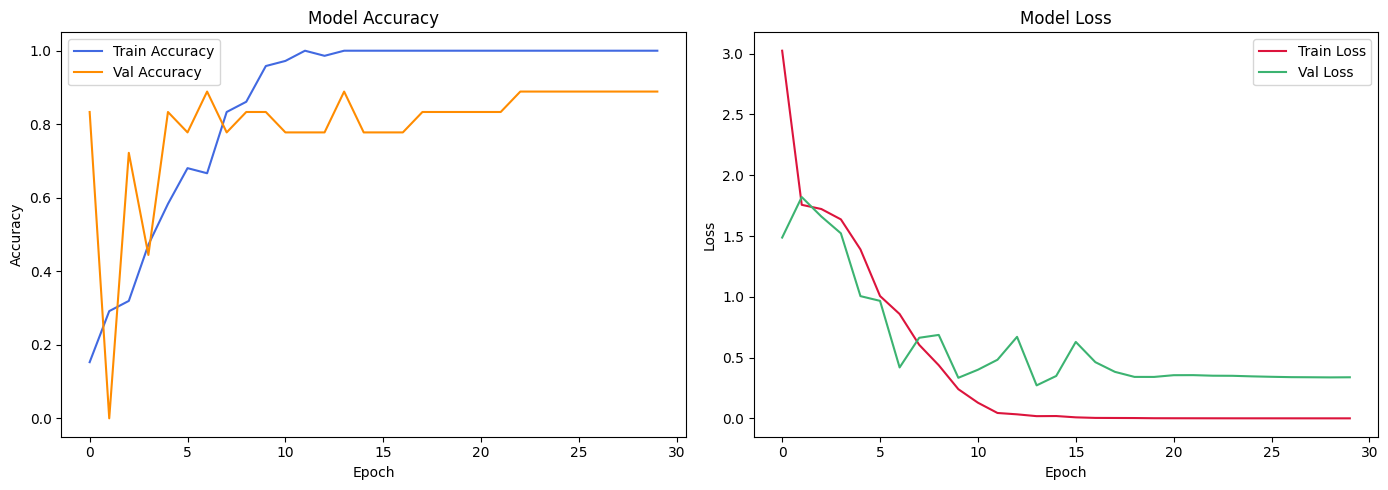

In [40]:
curve_fig, curve_axes = plt.subplots(1, 2, figsize=(14, 5))

curve_axes[0].plot(training_history.history['accuracy'],     label='Train Accuracy', color='royalblue')
curve_axes[0].plot(training_history.history['val_accuracy'], label='Val Accuracy',   color='darkorange')
curve_axes[0].set_title('Model Accuracy')
curve_axes[0].set_xlabel('Epoch')
curve_axes[0].set_ylabel('Accuracy')
curve_axes[0].legend()

curve_axes[1].plot(training_history.history['loss'],     label='Train Loss', color='crimson')
curve_axes[1].plot(training_history.history['val_loss'], label='Val Loss',   color='mediumseagreen')
curve_axes[1].set_title('Model Loss')
curve_axes[1].set_xlabel('Epoch')
curve_axes[1].set_ylabel('Loss')
curve_axes[1].legend()

plt.tight_layout()
plt.show()

#Task 5: Evaluate the Model
Model Evaluation
• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss

In [41]:
evaluation_loss, evaluation_acc = cnn_model.evaluate(testing_dataset)
print(f"Test Loss:     {evaluation_loss:.4f}")
print(f"Test Accuracy: {evaluation_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7000 - loss: 0.9412
Test Loss:     0.9412
Test Accuracy: 0.7000


#Task 6: Save and Load the Model
Model Saving and Loading
• Save the trained model to an .h5 file using model.save().
• Load the saved model and re-evaluate its performance on the test set

In [42]:
cnn_model.save('cnn_fruits_model.h5')
print("Model saved as cnn_fruits_model.h5")

restored_model = keras.models.load_model('cnn_fruits_model.h5')
restored_loss, restored_acc = restored_model.evaluate(testing_dataset)
print(f"Loaded Model - Test Loss: {restored_loss:.4f} | Test Accuracy: {restored_acc:.4f}")

Model saved as cnn_fruits_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.7000 - loss: 0.9412
Loaded Model - Test Loss: 0.9412 | Test Accuracy: 0.7000


#Task 7: Predictions and Classification Report
Making Predictions
• Use model.predict() to make predictions on test images.
• Convert the model’s predicted probabilities to digit labels using np.argmax().
• Also use from sklearn.metrics import classification
Report of your Model Performance

In [43]:
actual_labels, predicted_labels = [], []

for image_batch, label_batch in testing_dataset:
    batch_predictions = restored_model.predict(image_batch, verbose=0)
    predicted_labels.extend(np.argmax(batch_predictions, axis=1))
    actual_labels.extend(label_batch.numpy())

print(classification_report(actual_labels, predicted_labels, target_names=category_list))

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.56      1.00      0.71         5
     guarana       0.75      0.60      0.67         5
     pupunha       0.80      0.80      0.80         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.70        30
   macro avg       0.75      0.70      0.68        30
weighted avg       0.75      0.70      0.68        30

